# **IISc-Arm Instruction Enhancement Program (IEP) on Edge AI**
## website: https://cds.iisc.ac.in/faculty/simmhan/conf/arm-iep-2026/

# Author: Dr. Pandarasamy Arjunan and Students
## Center for Cyber Physical Systems, Indian Institute of Science.
## Contact: samy@iisc.ac.in


### References
 1. TinyML and Efficient Deep Learning Computing https://hanlab.mit.edu/courses/2024-fall-65940
 2. Various internet sources


# Lab 2: Model Parameters & Efficiency Metrics for MLP Classifier (Activity Detection)

In this tutorial, you will build a Multi-Layer Perceptron (MLP) model to classify human activities using sensor data and analyze how neural networks behave internally. The objective is not only to train a model that predicts correctly, but also to understand how complex, memory-intensive, and computationally expensive the model is.

Most beginners evaluate models only using accuracy. However, in real-world machine learning systems, we must also analyze parameters, memory usage, computational cost, and efficiency. These factors determine whether a model can run on mobile devices, embedded systems, or large-scale production environments.

You will work with sensor data representing different activities such as jogging, typing, and walking. Using this data, you will train an MLP classifier and study its internal structure, learning behavior, and efficiency metrics such as FLOPs, MACs, and parameter counts.

![image.png](https://drive.usercontent.google.com/download?id=1ZNqZd708aCVLiYOG-H1K3hUrq2RXSI_p&export=download&authuser=0)

This tutorial focuses on:
- performance metrics
- parameter analysis
- memory usage
- computational cost
- weight behavior

The goal is not just to train a model, but to understand how efficient and deployable it is.


---

## Think Before You Begin

1. Is this problem:
   - Regression
   - Classification
   - Clustering

2. What type of data are we using?
   - Images
   - Text
   - Sensor / tabular

3. Which model is most suitable?
   - CNN
   - MLP
   - RNN

Write your answers before proceeding.

**Answers**

## Import Libraries

In this section, we import the libraries required for building and analyzing the machine learning model. Pandas and NumPy help with data handling and numerical operations. Scikit-learn provides the MLP classifier and evaluation tools. Matplotlib and Seaborn help visualize data patterns and model results, while NetworkX is used to visualize the neural network architecture.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid')

import networkx as nx

## Load Dataset

We load three separate datasets representing different human activities: jogging, typing, and walking. Each dataset contains sensor readings collected over time. These readings act as features that help the model identify the activity being performed. Understanding the dataset is important because the model will learn patterns directly from these sensor values.

### Observation Questions

1. What do you think each column represents?
2. Are all values numeric?
3. How might these features help identify an activity?
4. Do you expect all activities to look similar?


**Answers**

In [ ]:
jogging_df = pd.read_csv('jogging.csv', on_bad_lines='skip')
typing_df = pd.read_csv('typing.csv', on_bad_lines='skip')
walking_df = pd.read_csv('walking.csv', on_bad_lines='skip')

print("Jogging shape:", jogging_df.shape)
print("Typing shape:", typing_df.shape)
print("Walking shape:", walking_df.shape)

Jogging shape: (5200, 11)
Typing shape: (5200, 11)
Walking shape: (5200, 11)


## Data Cleaning

Real-world data often contains noise, missing values, and irrelevant features. In this section, we remove unnecessary columns and handle missing values. Cleaning the dataset ensures that the model learns from meaningful information rather than noise, which improves prediction accuracy and stability.

### Think and Answer

1. Why are we removing columns like gx, gy, gz?
2. What happens if noisy features remain in the dataset?
3. Will model accuracy increase or decrease if irrelevant features are used?

Write your reasoning before running the cleaning step.

In [ ]:
drop_cols = ['Sequence No', 'Buffer_Size','gx','gy','gz','mx','my','mz']

jogging_df = jogging_df.drop(columns=drop_cols)
typing_df = typing_df.drop(columns=drop_cols)
walking_df = walking_df.drop(columns=drop_cols)

jogging_df.dropna(inplace=True)
typing_df.dropna(inplace=True)
walking_df.dropna(inplace=True)

## Exploratory Data Analysis

Before training any model, it is essential to understand the data. We visualize sensor readings for jogging, typing, and walking to observe patterns and differences. This helps us understand how activities vary and which features might be important for classification. Visualization builds intuition about what the model will learn.

We visualize sensor patterns for:
- jogging
- typing
- walking

### Analyze the Graphs

1. Which activity looks most dynamic?
2. Which activity looks stable?
3. Which one might be easiest to classify?
4. Which one might confuse the model?

Observe carefully before moving ahead.

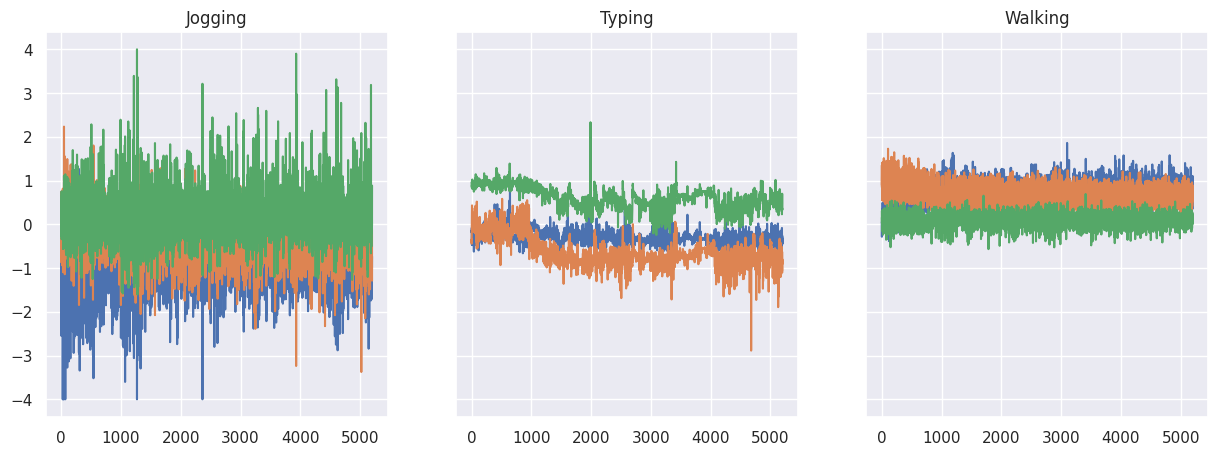

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(15,5), sharey=True)

jogging_df.plot(ax=ax[0], legend=False)
ax[0].title.set_text('Jogging')

typing_df.plot(ax=ax[1], legend=False)
ax[1].title.set_text('Typing')

walking_df.plot(ax=ax[2], legend=False)
ax[2].title.set_text('Walking')

## Create Target Labels

Machine learning models require labeled data to learn. In this step, we assign a target label to each dataset representing the activity type. These labels act as the ground truth for the classifier and guide the learning process.

We assign labels to each activity.


### Concept Check

1. Why does the model need a target column?
2. What happens if target labels are incorrect?
3. Can a model learn without labels?

Write your answers.



In [ ]:
jogging_df['Target'] = 'Jog'
typing_df['Target'] = 'Typ'
walking_df['Target'] = 'Walk'

## Merge Dataset

We combine all activity datasets into a single dataset. This creates a multi-class classification problem where the model must distinguish between jogging, typing, and walking based on sensor readings. This step prepares the data for model training.

In [ ]:
df = pd.concat([jogging_df, typing_df, walking_df])
df.head()

,ax,ay,az,Target
0,-0.804443,0.004028,0.156494,Jog
1,-1.357178,-0.781250,0.067139,Jog
2,-0.964477,-0.099731,0.027710,Jog
3,-2.551392,0.747803,0.563721,Jog
4,-0.387207,-0.700195,-0.101562,Jog


## Dataset Overview

In [ ]:
df.info()
df.describe()

df.groupby('Target').describe().T


<class 'pandas.core.frame.DataFrame'>
Index: 15600 entries, 0 to 5199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ax      15600 non-null  float64
 1   ay      15600 non-null  float64
 2   az      15600 non-null  float64
 3   Target  15600 non-null  object 
dtypes: float64(3), object(1)
memory usage: 609.4+ KB


Target            Jog          Typ         Walk
ax count  5200.000000  5200.000000  5200.000000
   mean     -1.022133    -0.300759     0.684254
   std       0.488082     0.153836     0.257300
   min      -3.999512    -1.178467    -0.383789
   25%      -1.260651    -0.390015     0.561462
   50%      -0.981750    -0.315857     0.708801
   75%      -0.729340    -0.222534     0.837891
   max       1.268066     0.971802     1.859375
ay count  5200.000000  5200.000000  5200.000000
   mean     -0.318201    -0.618747     0.687579
   std       0.453732     0.335210     0.235571
   min      -3.375366    -2.886475    -0.128906
   25%      -0.589966    -0.829376     0.544342
   50%      -0.307617    -0.707275     0.688110
   75%      -0.033569    -0.483887     0.832275
   max       2.232422     0.581909     1.727417
az count  5200.000000  5200.000000  5200.000000
   mean      0.126321     0.597030     0.086875
   std       0.502828     0.240163     0.144233
   min      -1.604492    -0.244385    -0.567627
   25%      -0.163849     0.417969     0.002655
   50%       0.051697     0.586243     0.085266
   75%       0.351593     0.777374     0.179016
   max       3.999512     2.332520     0.692505

## Feature & Target Split

The dataset contains two types of information:
- features (sensor readings)
- target labels (activity type)

We separate these so that the model learns relationships between features and target values.

In [ ]:
cols = df.columns.drop('Target')

X = df[cols]
y = df['Target']

## Feature & Target Split

To evaluate how well the model generalizes, we divide the dataset into training and testing sets. The training set is used to teach the model patterns, while the testing set is used to evaluate its performance on unseen data. This helps ensure the model does not simply memorize the data.

We divide data into:
- training set
- testing set

### Think Like a Data Scientist

1. Why should we not train on the entire dataset?
2. What happens if we test on training data?
3. What is generalization?



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)


Training shape: (12480, 3)


## Build MLP Model

The Multi-Layer Perceptron (MLP) is a feed-forward neural network consisting of an input layer, one or more hidden layers, and an output layer. It learns patterns by adjusting weights and biases during training. This architecture is suitable for tabular and sensor-based data because it can capture relationships between multiple numerical features.

MLP consists of:
- input layer
- hidden layer
- output layer

### Task

1. Which layer will have the most parameters?
2. What happens if we increase neurons?
3. What happens if we add more hidden layers?


In [ ]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(10,),
    random_state=1,
    max_iter=200
)

### Train Model

During training, the model learns to map sensor readings to activity labels. It updates weights iteratively to reduce prediction errors. Over time, it becomes better at identifying patterns associated with each activity.

### Learning Reflection

1. Do you think training will take long?
2. Will model converge quickly?
3. What affects training speed?


In [ ]:
mlp_model.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(10,), random_state=1)

### Predictions

In [ ]:
y_pred = mlp_model.predict(X_test)

## Performance Evaluation

After training, we evaluate the model using performance metrics such as accuracy, precision, recall, and F1-score. The confusion matrix helps visualize which activities are predicted correctly and which are misclassified. This step helps assess how well the model learned from the data.

We evaluate using:
- accuracy
- confusion matrix
- classification report

### Confusion Matrix Thinking

1. Which activity might be hardest to classify?
2. Which activities may get confused?
3. Why?


              precision    recall  f1-score   support

         Jog      0.982     0.978     0.980      1038
         Typ      0.982     0.984     0.983      1083
        Walk      0.996     0.998     0.997       999

    accuracy                          0.987      3120
   macro avg      0.987     0.987     0.987      3120
weighted avg      0.987     0.987     0.987      3120



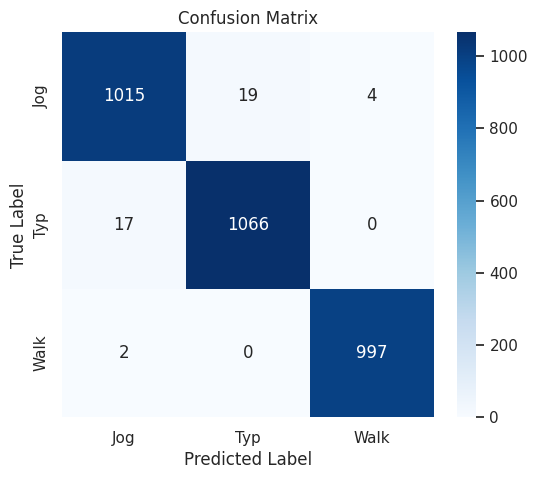

In [ ]:
print(metrics.classification_report(y_test, y_pred, digits=3))

cm = metrics.confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Visualize MLP Architecture

We visualize the structure of the neural network to understand how neurons are connected across layers. This helps us interpret how information flows through the model and how many connections exist between layers.

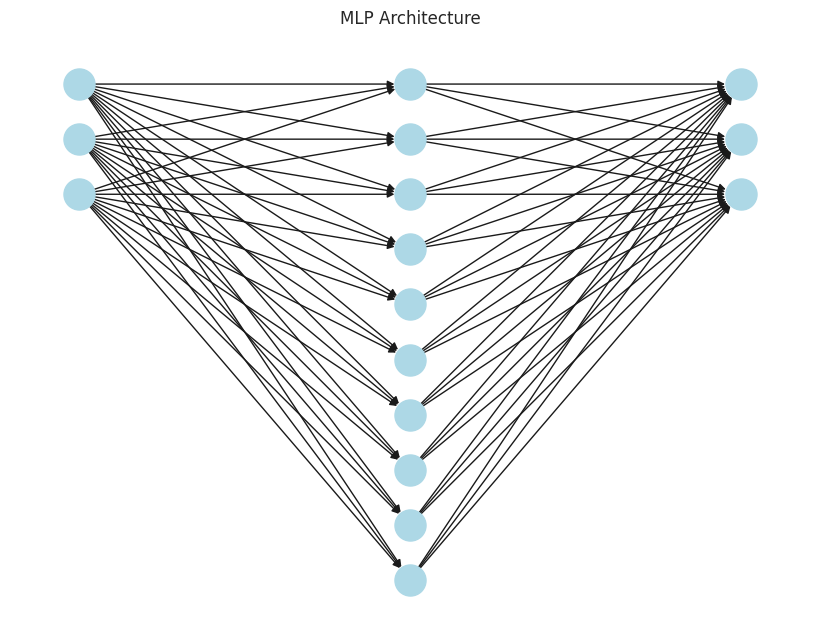

In [ ]:
def plot_mlp(mlp, X_train):

    layer_sizes = [X_train.shape[1]] + list(mlp.hidden_layer_sizes) + [mlp.n_outputs_]

    G = nx.DiGraph()
    positions = {}
    x_offset = 0

    for layer_idx, num_nodes in enumerate(layer_sizes):
        for node in range(num_nodes):
            node_name = f"L{layer_idx}_N{node}"
            G.add_node(node_name)
            positions[node_name] = (x_offset, -node)
        x_offset += 1

    for layer_idx in range(len(layer_sizes)-1):
        for src in range(layer_sizes[layer_idx]):
            for dest in range(layer_sizes[layer_idx+1]):
                G.add_edge(f"L{layer_idx}_N{src}", f"L{layer_idx+1}_N{dest}")

    plt.figure(figsize=(8,6))
    nx.draw(G, pos=positions, node_size=500, node_color="lightblue")
    plt.title("MLP Architecture")
    plt.show()

plot_mlp(mlp_model, X_train)

## Model Parameter

Parameters include weights and biases learned by the model. The total number of parameters indicates how complex the model is. More parameters allow the model to learn complex relationships but increase memory usage and computational cost. Understanding parameter count is essential for designing efficient models.

Parameters = weights + biases

**Question**

If hidden neurons increase:

- parameters increase or decrease?
- memory increase or decrease?
- FLOPs increase or decrease?



### Memory Footprint

In this section, we estimate the memory required to store the model. Model size depends on the number of parameters and how they are stored. Memory usage becomes critical when deploying models on devices with limited resources such as wearables or mobile phones.


### Deployment

Where is memory most critical?

- mobile device
- smartwatch
- cloud server

Which requires smallest model?


In [ ]:
num_params = sum(w.size for w in mlp_model.coefs_) + sum(b.size for b in mlp_model.intercepts_)
model_size = num_params * np.float32().nbytes

total_activations = sum(mlp_model.hidden_layer_sizes) + mlp_model.n_outputs_
peak_activations = max(mlp_model.hidden_layer_sizes + (mlp_model.n_outputs_,))

print("Number of Parameters:", num_params)
print("Model Size (Bytes):", model_size)
print("Total Activations:", total_activations)
print("Peak Activations:", peak_activations)

Number of Parameters: 73
Model Size (Bytes): 292
Total Activations: 13
Peak Activations: 10


## Layer-wise Parameter Breakdown

Different layers contribute differently to model complexity. This section analyzes how many parameters each layer contains and how much memory each contributes. It helps identify which part of the model is computationally heavy.

### Thinking

1. Which contributes more parameters?
   - input → hidden
   - hidden → output

2. Why?

In [ ]:
input_size = X_train.shape[1]
hidden_layers = mlp_model.hidden_layer_sizes
output_size = mlp_model.n_outputs_

layer_sizes = [input_size] + list(hidden_layers) + [output_size]

print("\nLayer-wise Parameter Breakdown")

total_params = 0

for i in range(len(layer_sizes)-1):

    num_weights = layer_sizes[i] * layer_sizes[i+1]
    num_biases = layer_sizes[i+1]
    layer_params = num_weights + num_biases

    total_params += layer_params

    print(f"\nLayer {i+1}: {layer_sizes[i]} → {layer_sizes[i+1]}")
    print(f"Weights: {num_weights}")
    print(f"Biases: {num_biases}")
    print(f"Total params: {layer_params}")

print("\nTotal parameters:", total_params)



Layer-wise Parameter Breakdown

Layer 1: 3 → 10
Weights: 30
Biases: 10
Total params: 40

Layer 2: 10 → 3
Weights: 30
Biases: 3
Total params: 33

Total parameters: 73


## Computation Metrics

Computational efficiency is measured using MACs (Multiply-Accumulate Operations) and FLOPs (Floating Point Operations). These metrics estimate how much computation is required when the model makes predictions. Models with high FLOPs require more processing power and time.

### FLOPs & MACs

These measure computational cost.


Which affects computation most?

- features
- neurons
- layers


In [ ]:
total_MACs = 0

for i in range(len(layer_sizes)-1):
    num_MACs = layer_sizes[i] * layer_sizes[i+1]
    total_MACs += num_MACs
    print(f"Layer {i+1} MACs:", num_MACs)

total_FLOPs = 2 * total_MACs

inference_time = 0.001
FLOPS = total_FLOPs / inference_time

print("\nTotal MACs:", total_MACs)
print("Total FLOPs:", total_FLOPs)
print("Estimated FLOPS:", FLOPS)

Layer 1 MACs: 30
Layer 2 MACs: 30

Total MACs: 60
Total FLOPs: 120
Estimated FLOPS: 120000.0


## Weight & Bias Distribution

Weights represent the strength of connections between neurons. Visualizing them helps understand how the model has learned relationships between features. Patterns in weight matrices indicate which inputs influence predictions more strongly.

Weights represent the strength of connections between neurons. Visualizing them helps understand how the model has learned relationships between features. Patterns in weight matrices indicate which inputs influence predictions more strongly.

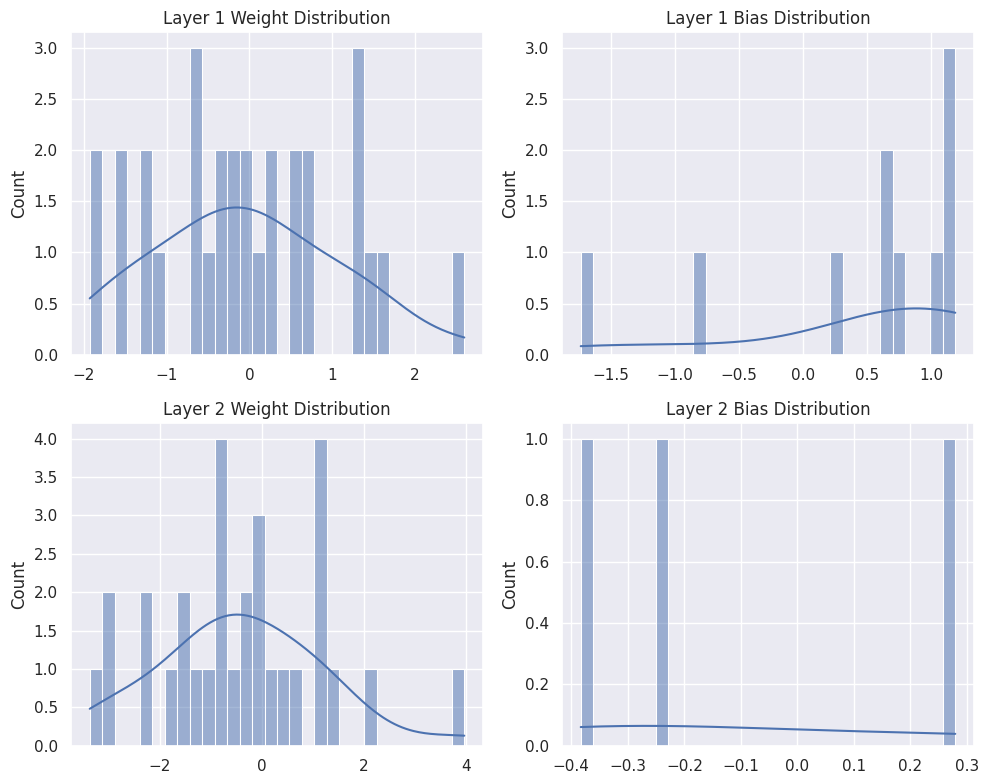

In [ ]:
def plot_distributions(mlp_model):

    num_layers = len(mlp_model.coefs_)
    fig, axes = plt.subplots(num_layers, 2, figsize=(10,8))

    for i in range(num_layers):
        weights = mlp_model.coefs_[i].flatten()
        biases = mlp_model.intercepts_[i]

        sns.histplot(weights, bins=30, kde=True, ax=axes[i,0])
        axes[i,0].set_title(f"Layer {i+1} Weight Distribution")

        sns.histplot(biases, bins=30, kde=True, ax=axes[i,1])
        axes[i,1].set_title(f"Layer {i+1} Bias Distribution")

    plt.tight_layout()
    plt.show()

plot_distributions(mlp_model)


## Overall Distribution

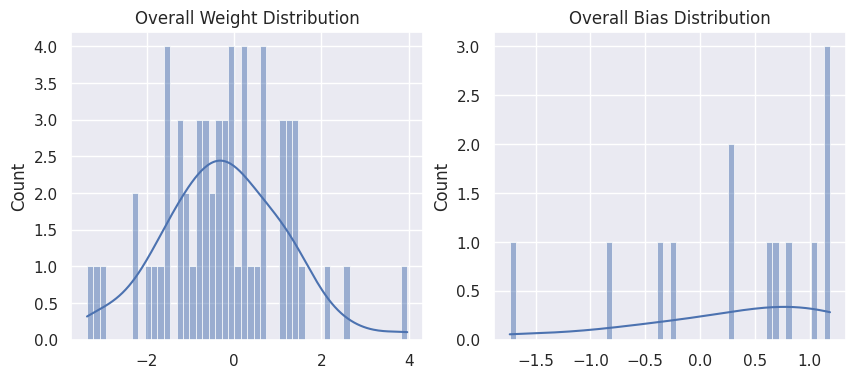

In [ ]:
all_weights = np.concatenate([w.flatten() for w in mlp_model.coefs_])
all_biases = np.concatenate([b.flatten() for b in mlp_model.intercepts_])

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(all_weights, bins=50, kde=True)
plt.title("Overall Weight Distribution")

plt.subplot(1,2,2)
sns.histplot(all_biases, bins=50, kde=True)
plt.title("Overall Bias Distribution")

plt.show()

## Results Table

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Metric": ["Accuracy", "Parameters", "Model Size", "MACs", "FLOPs"],
    "Value": [
        metrics.accuracy_score(y_test, y_pred),
        num_params,
        model_size,
        total_MACs,
        total_FLOPs
    ]
})

results

,Metric,Value
0,Accuracy,0.986538
1,Parameters,73.000000
2,Model Size,292.000000
3,MACs,60.000000
4,FLOPs,120.000000


# Final Summary

Summarize key observations such as accuracy, parameter count, memory usage, and computational cost. This helps connect performance with efficiency and understand trade-offs.

Fill this table:

| Observation | Answer |
|---|---|
| Most parameter-heavy layer | |
| Most compute-heavy layer | |
| Trade-off observed | |
| Key learning | |


This tutorial demonstrates that evaluating a neural network requires more than measuring accuracy. Understanding parameters, memory usage, and computational efficiency is essential for building practical machine learning systems.

By completing this tutorial, you have learned:
- how MLP models work
- how to evaluate performance
- how to analyze parameters and memory
- how to compute efficiency metrics
- how to interpret neural network behavior
- how to think about deployment constraints

These concepts form the foundation for designing scalable, efficient, and deployable AI systems.

------------------------------------------------------------THE END ------------------------------------------------------